# Inverse beamforming on a CIRS phantom scan

This tutorial applies [`zea.inverse`](../../_autosummary/zea.inverse.rst) to a recorded
acquisition of a **simulated CIRS point-scatterer phantom** (3 plane waves, 80 elements,
simulated with FIELD II, ground-truth scatterer positions included) and reproduces the
phantom results of the standalone
[DAS-inversion study](https://github.com/sankethvedula/das-inverse) that `zea.inverse`
was ported from. We recover the **pre-beamformed channel data** from the
**post-beamformed image** alone and compare it against the recorded channel data. The
reference numbers we aim to reproduce (from the original study):

| inversion | pre-BF corr | post-BF corr |
|-----------|:-----------:|:------------:|
| direct pseudo-inverse | 0.56 | 1.00 |
| scatterer prior (15k) | 0.84 | 0.996 |

For a fully synthetic walkthrough see the
[introductory tutorial](fish_example.ipynb); for in-vivo data continue
with the [carotid tutorial](carotid_example.ipynb).

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tue-bmd/zea/blob/main/docs/source/notebooks/inverse/cirs_example.ipynb)
[![View on GitHub](https://img.shields.io/badge/GitHub-View%20Source-blue?logo=github)](https://github.com/tue-bmd/zea/blob/main/docs/source/notebooks/inverse/cirs_example.ipynb)

‼️ **Important:** This notebook is optimized for **GPU/TPU**. Code execution on a **CPU** may be very slow.

If you are running in Colab, please enable a hardware accelerator via:

**Runtime → Change runtime type → Hardware accelerator → GPU/TPU** 🚀.

In [1]:
%%capture
%pip install zea

In [2]:
import os

os.environ["KERAS_BACKEND"] = "jax"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import time
import urllib.request
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
from keras import ops
from matplotlib.animation import FuncAnimation, PillowWriter

import zea
from zea.inverse import DASOperator, ScattererSimulator, invert_direct, invert_scatterers

zea.init_device()

zea: Using backend 'jax'


-------------------GPU settings-------------------
0/1 GPUs were disabled
     memory
GPU        
0       81072
Selecting 1 GPU based on available memory.
Selected GPU 0 with Free Memory: 81072.00 MiB
--------------------------------------------------


'gpu:0'

In [3]:
# Parameters (overridden for fast CI runs, see tests/test_notebooks.py)
# CGLS is stopped early: on ill-posed problems the iteration count doubles as
# the regularization parameter, and 40 iterations capture nearly all of the
# attainable correlation at a fraction of the runtime.
n_iter = 40
n_scatterers = 15000

## Download the scan

The CIRS phantom scan (2 MB, simulated with FIELD II, ground-truth scatterers included)
comes from the original study's repository. It is in the (legacy) `zea` HDF5 format and
loads directly with [`zea.File`](../../_autosummary/zea.data.file.rst).

In [4]:
DATA_DIR = Path(os.environ.get("ZEA_INVERSE_DATA_DIR", "~/zea-inverse-data")).expanduser()
DATA_DIR.mkdir(parents=True, exist_ok=True)

SCAN_PATH = DATA_DIR / "cirs_simulated.hdf5"
SCAN_URL = (
    "https://raw.githubusercontent.com/sankethvedula/das-inverse/main/data/cirs_simulated.hdf5"
)

if SCAN_PATH.exists():
    print(f"{SCAN_PATH.name}: already downloaded")
else:
    print(f"downloading {SCAN_PATH.name} ...")
    urllib.request.urlretrieve(SCAN_URL, SCAN_PATH)
    print(f"  -> {SCAN_PATH} ({SCAN_PATH.stat().st_size / 1e6:.0f} MB)")

cirs_simulated.hdf5: already downloaded


## Loading a scan for inversion

We load the acquisition into [`zea.Parameters`](../../parameters_doc.rst) with a few
overrides that match the conventions of the original study:

- **`t_peak`**: the original beamformer used the two-way waveform's time-to-peak,
  *doubled* (a jaxus convention). We override `t_peak` accordingly so the delay model
  matches exactly.
- **`element_width`**: these legacy files store the element width under `scan/`, which
  the legacy loader drops — we read it directly and pass it as an override (it drives
  the element directivity model in the simulator).
- **grid**: a 0.6-wavelength pixel grid over the imaging region, and a receive
  f-number of 1.5 (the original configuration).

In [5]:
def load_scan(path, region, pixels_per_wavelength=1 / 0.6, f_number=1.5, frame=0):
    """Load a scan and its raw RF data with the original study's conventions."""
    with h5py.File(path, "r") as h:
        element_width = float(h["scan/element_width"][()])
    with zea.File(path) as file:
        parameters = file.load_parameters()
        raw_data = np.asarray(file["data/raw_data"][frame, ..., 0], dtype=np.float32)

    # t_peak: two-way waveform peak time, doubled (jaxus/original-study convention)
    waveform = np.asarray(parameters.waveforms_two_way[0])
    t_peak = np.full(parameters.n_tx, 2.0 * np.argmax(waveform) / 250e6, dtype=np.float32)

    # 0.6-wavelength pixel grid over the requested region
    spacing = parameters.sound_speed / float(np.mean(parameters.center_frequency))
    spacing = spacing / pixels_per_wavelength
    grid_size_x = int((region[1] - region[0]) / spacing) + 1
    grid_size_z = int((region[3] - region[2]) / spacing) + 1

    with zea.File(path) as file:
        parameters = file.load_parameters(
            t_peak=t_peak,
            element_width=element_width,
            f_number=f_number,
            xlims=(region[0], region[1]),
            zlims=(region[2], region[3]),
            grid_size_x=grid_size_x,
            grid_size_z=grid_size_z,
        )
    print(
        f"{Path(path).name}: n_tx={parameters.n_tx} n_el={parameters.n_el} "
        f"n_ax={parameters.n_ax} grid=({grid_size_z}, {grid_size_x})"
    )
    return parameters, raw_data


def correlation(a, b):
    """Absolute normalized correlation between two arrays."""
    a = np.asarray(ops.convert_to_numpy(a)).ravel()
    b = np.asarray(ops.convert_to_numpy(b)).ravel()
    a, b = a - a.mean(), b - b.mean()
    return abs(np.vdot(a, b)) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-30)


def report(label, result, raw_data, image, reference):
    """Print pre/post-beamforming correlations next to the reference values."""
    pre = correlation(result.channel_data, raw_data)
    post = correlation(result.image, image)
    print(
        f"{label:28s} pre-BF corr {pre:.3f} (reference {reference[0]:.3f})   "
        f"post-BF corr {post:.3f} (reference {reference[1]:.3f})"
    )
    return pre, post

## Rendering helpers

`show_images` compares the measured image with the re-beamformed reconstruction
(log-compressed `|RF|`, as in the original study). `render_prebf_gif` animates the
recovered pre-beamformed channel data across transmits next to the recorded ground
truth — this is the quantity being recovered, which the inversion never observes.

In [6]:
def to_db(image_2d):
    magnitude = np.abs(image_2d)
    return 20 * np.log10(magnitude / (magnitude.max() + 1e-12) + 1e-6)


def show_images(operator, image, result, region, scatterers=None, title=""):
    extent = [region[0] * 1e3, region[1] * 1e3, region[3] * 1e3, region[2] * 1e3]
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    panels = [(image, "measured image"), (result.image, "re-beamformed reconstruction")]
    for ax, (flat, label) in zip(axes, panels):
        ax.imshow(
            to_db(ops.convert_to_numpy(operator.to_grid(flat))),
            cmap="gray",
            vmin=-50,
            vmax=0,
            extent=extent,
            aspect="equal",
        )
        if scatterers is not None:
            ax.scatter(
                scatterers[:, 0] * 1e3,
                scatterers[:, 2] * 1e3,
                s=16,
                facecolors="none",
                edgecolors="r",
                linewidths=0.8,
            )
        ax.set(title=label, xlabel="x [mm]", ylabel="z [mm]")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def render_prebf_gif(filename, channel_data_true, channel_data_recon, transmits, fps=10):
    """Animate ground-truth vs recovered channel data across transmits."""
    gt = np.asarray(ops.convert_to_numpy(channel_data_true))
    recon = np.asarray(ops.convert_to_numpy(channel_data_recon))
    fig, axes = plt.subplots(1, 2, figsize=(7, 4.5))

    def draw(tx):
        for ax in axes:
            ax.clear()
        for ax, cube, label in zip(axes, [gt, recon], ["recorded pre-BF", "recovered pre-BF"]):
            ax.imshow(
                np.abs(cube[tx]),
                aspect="auto",
                cmap="viridis",
                vmax=np.percentile(np.abs(cube[tx]), 99.5) + 1e-12,
            )
            ax.set(title=label, xlabel="element", ylabel="sample")
        tx_corr = correlation(recon[tx], gt[tx])
        fig.suptitle(f"transmit {tx + 1}/{gt.shape[0]}   corr {tx_corr:.3f}")
        fig.tight_layout()

    animation = FuncAnimation(fig, draw, frames=list(transmits), interval=1000 / fps)
    animation.save(filename, writer=PillowWriter(fps=fps))
    plt.close(fig)
    print(f"saved {filename} ({Path(filename).stat().st_size / 1e6:.1f} MB)")

## CIRS phantom: pseudo-inverse vs scatterer prior

We beamform the recorded channel data once to get the *measured image* — from here on,
the inversions see only that image. The direct method runs CGLS on the full channel-data
cube (the minimum-norm solution); the scatterer prior seeds 15,000 scatterers from the
image envelope and solves for their magnitudes.

In [7]:
REGION_CIRS = (-0.032, 0.032, 0.003, 0.095)

parameters, raw_data = load_scan(SCAN_PATH, REGION_CIRS)
with h5py.File(SCAN_PATH, "r") as h:
    scatterers_true = np.asarray(h["phantom/scatterer_positions"])

operator = DASOperator(parameters)
image = operator.forward(raw_data)

start = time.time()
result_direct = invert_direct(operator, image, n_iter=n_iter)
print(f"direct inversion: {time.time() - start:.0f}s")
report("CIRS direct pseudo-inverse", result_direct, raw_data, image, (0.557, 1.000))

start = time.time()
simulator = ScattererSimulator(parameters, chunk_size=8192)
result_cirs = invert_scatterers(
    operator, image, n_scatterers=n_scatterers, n_iter=n_iter, seed=0, simulator=simulator
)
print(f"scatterer-prior inversion: {time.time() - start:.0f}s")
report("CIRS scatterer prior (15k)", result_cirs, raw_data, image, (0.838, 0.996));

zea: WARNING This ``zea.File`` '/nfs/scistore20/bronsgrp/svedula/das-inversion/data/cirs_simulated.hdf5' was created with a legacy version of zea (<0.1.0), while you are using zea v0.1.2. It may behave in unexpected ways. Install an earlier version of zea<0.1.0 for full compatibility or re-save the file with zea v0.1.0 or later (e.g. via File.create).


zea: WARNING The waveforms_one_way parameter is stored as a dictionary in the file. Converting to array. This will be deprecated in future versions of zea. Please update your files to store waveforms as arrays of shape `(n_tx, n_samples)`.


zea: WARNING The waveforms_two_way parameter is stored as a dictionary in the file. Converting to array. This will be deprecated in future versions of zea. Please update your files to store waveforms as arrays of shape `(n_tx, n_samples)`.


zea: WARNING The waveforms_one_way parameter is stored as a dictionary in the file. Converting to array. This will be deprecated in future versions of zea. Please update your files to store waveforms as arrays of shape `(n_tx, n_samples)`.


zea: WARNING The waveforms_two_way parameter is stored as a dictionary in the file. Converting to array. This will be deprecated in future versions of zea. Please update your files to store waveforms as arrays of shape `(n_tx, n_samples)`.


cirs_simulated.hdf5: n_tx=3 n_el=80 n_ax=2048 grid=(312, 217)


zea: WARNING width/grid_size_x = 0.0002949 > wavelength/2 = 0.0002464. Consider increasing grid_size_x to 260 or more, or unsetting it to size the grid automatically.


zea: WARNING depth/grid_size_z = 0.0002949 > wavelength/2 = 0.0002464. Consider increasing grid_size_z to 374 or more, or unsetting it to size the grid automatically.


direct inversion: 3s
CIRS direct pseudo-inverse   pre-BF corr 0.556 (reference 0.557)   post-BF corr 1.000 (reference 1.000)


scatterer-prior inversion: 17s
CIRS scatterer prior (15k)   pre-BF corr 0.842 (reference 0.838)   post-BF corr 0.993 (reference 0.996)


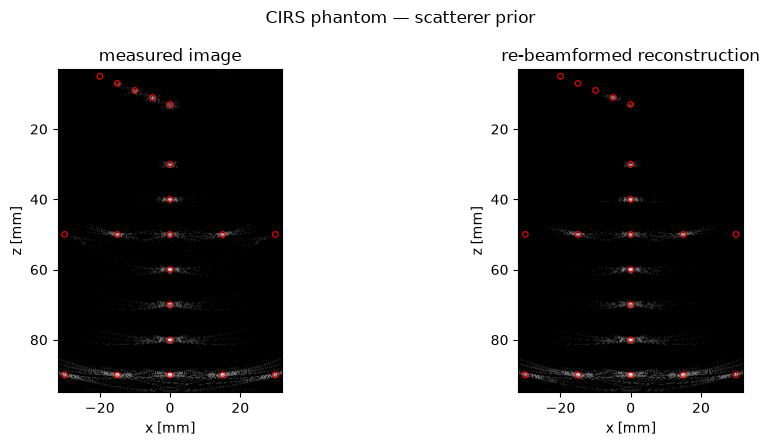

saved cirs_prebf.gif (0.1 MB)


In [8]:
show_images(
    operator,
    image,
    result_cirs,
    REGION_CIRS,
    scatterers=scatterers_true,
    title="CIRS phantom — scatterer prior",
)
render_prebf_gif(
    "cirs_prebf.gif",
    raw_data,
    result_cirs.channel_data,
    transmits=range(parameters.n_tx),
    fps=2,
)

![CIRS pre-beamformed channel data: recorded vs recovered](cirs_prebf.gif)

The recovered channel data reproduces the scatterer hyperbolae of the recorded data —
the scatterer prior has filled the nullspace of the beamformer with physically
consistent echoes. Compare the direct pseudo-inverse, which fits the image perfectly
(post-BF corr 1.00) yet correlates far less with the true channel data.

## Takeaways

- Both inversions reproduce the reference results of the
  [original study](https://github.com/sankethvedula/das-inverse) (small differences in
  the third digit come from a different random seeding stream and pixel-grid rounding).
- **Post-beamformed fit is easy; pre-beamformed recovery is the hard part.** The
  pseudo-inverse drives the image error to zero while recovering little of the channel
  data — the DAS operator sums ~`n_el x n_tx` samples per pixel, so almost everything
  about the channel data lives in its nullspace.
- A **physical scatterer prior** closes most of that gap on point targets (pre-BF corr
  0.56 → 0.84). How much survives on diffuse in-vivo tissue? Continue with the
  [carotid tutorial](carotid_example.ipynb).